In [1]:
import os

# Path of the main dataset folder
dataset_path = r"C:\Users\HP\Downloads\archive\Garbage classification"

# Get all folders inside the dataset
classes = os.listdir(dataset_path)

# Display the class names
for class_name in classes:
    print(class_name)

total_images = 0

for class_name in classes:

    # Create the path of the current class folder
    class_path = os.path.join(dataset_path, class_name)

    # Make sure it is a folder
    if os.path.isdir(class_path):

        # Count files inside the folder
        image_count = len(os.listdir(class_path))

        print("In",class_name, ":", "the no of folders in garbage classification:",image_count)

        # Add to total
        total_images += image_count

Garbage classification
In Garbage classification : the no of folders in garbage classification: 6


In [2]:
import os

# Parent folder
parent_path = r"C:\Users\HP\Downloads\archive"

# Show everything inside the parent folder
print(os.listdir(parent_path))

['Garbage classification', 'one-indexed-files-notrash_test.txt', 'one-indexed-files-notrash_train.txt', 'one-indexed-files-notrash_val.txt', 'one-indexed-files.txt', 'zero-indexed-files.txt']


In [3]:
import os

# Path to the actual dataset folder
dataset_path = r"C:\Users\HP\Downloads\archive\Garbage classification"

# Display everything inside the dataset folder
print(os.listdir(dataset_path))

['Garbage classification']


In [4]:
import os

# Actual folder containing the six classes
dataset_path = r"C:\Users\HP\Downloads\archive\Garbage classification\Garbage classification"

# Show the contents
print("The different classes in garbage classification:",os.listdir(dataset_path))

The different classes in garbage classification: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']


In [5]:
import os

# Path of the actual dataset
dataset_path = r"C:\Users\HP\Downloads\archive\Garbage classification\Garbage classification"

# List of our 6 classes
classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Variable to store total number of images
total_images = 0

print("Number of images in each class:\n")

# Go through each class
for class_name in classes:

    # Create the path of the class folder
    class_path = os.path.join(dataset_path, class_name)

    # Count files inside the class folder
    image_count = len(os.listdir(class_path))

    # Display the count
    print(class_name, ":", image_count)

    # Add to total
    total_images = total_images + image_count

# Display total
print("\nTotal number of images:", total_images)

Number of images in each class:

cardboard : 403
glass : 501
metal : 410
paper : 594
plastic : 482
trash : 137

Total number of images: 2527


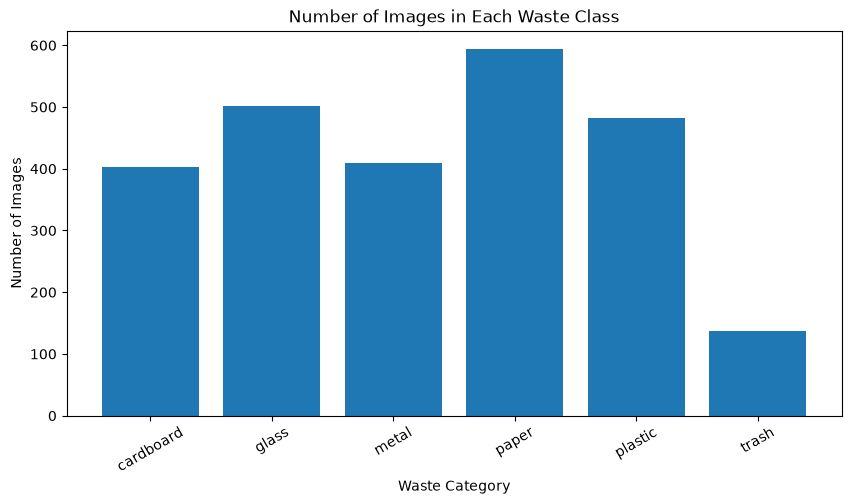

In [6]:
import matplotlib.pyplot as plt

# Class names
classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Number of images in each class
image_counts = [
    403,
    501,
    410,
    594,
    482,
    137
]

# Create the bar chart
plt.figure(figsize=(10, 5))

plt.bar(classes, image_counts)

# Add title
plt.title("Number of Images in Each Waste Class")

# Add labels
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")

# Rotate class names slightly for readability
plt.xticks(rotation=30)

# Display the chart
plt.show()

In [7]:
import os
from PIL import Image

# Path of the dataset
dataset_path = r"C:\Users\HP\Downloads\archive\Garbage classification\Garbage classification"

# List of classes
classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Store image dimensions
image_sizes = set()

# Store image modes
image_modes = set()

# Count successfully checked images
checked_images = 0

# Go through each class
for class_name in classes:

    # Path of the class folder
    class_path = os.path.join(dataset_path, class_name)

    # Go through every file
    for image_name in os.listdir(class_path):

        # Complete image path
        image_path = os.path.join(class_path, image_name)

        try:
            # Open the image
            image = Image.open(image_path)

            # Store width and height
            image_sizes.add(image.size)

            # Store image mode
            image_modes.add(image.mode)

            # Increase counter
            checked_images += 1

        except Exception as e:
            # Display files that cannot be opened
            print("Could not open:", image_path)

# Display results
print("Total images checked:", checked_images)

print("\nDifferent image dimensions:")
print(image_sizes)

print("\nImage modes:")
print(image_modes)

Total images checked: 2527

Different image dimensions:
{(512, 384)}

Image modes:
{'RGB'}


In [8]:
import tensorflow as tf
import os

# Path of the dataset
dataset_path = r"C:\Users\HP\Downloads\archive\Garbage classification\Garbage classification"

# Image size required by our transfer learning models
IMG_SIZE = (224, 224)

# Number of images processed at one time
BATCH_SIZE = 32

# Random seed for reproducible results
SEED = 42

# Number of classes
NUM_CLASSES = 6

print("TensorFlow version:", tf.__version__)
print("Image size:", IMG_SIZE)
print("Batch size:", BATCH_SIZE)
print("Number of classes:", NUM_CLASSES)

TensorFlow version: 2.21.0
Image size: (224, 224)
Batch size: 32
Number of classes: 6


In [9]:
# Create the training dataset
train_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="training",
    seed=SEED,
    shuffle=True
)

# Create the temporary dataset
temp_dataset = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    labels="inferred",
    label_mode="int",
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    validation_split=0.30,
    subset="validation",
    seed=SEED,
    shuffle=True
)

print("\nTraining dataset created.")
print("Temporary validation/test dataset created.")

Found 2527 files belonging to 6 classes.
Using 1769 files for training.
Found 2527 files belonging to 6 classes.
Using 758 files for validation.

Training dataset created.
Temporary validation/test dataset created.


In [10]:
# Count the number of batches in the temporary dataset
temp_batches = tf.data.experimental.cardinality(temp_dataset).numpy()

# Calculate half of the temporary batches
test_batches = temp_batches // 2

# First half → validation
validation_dataset = temp_dataset.take(test_batches)

# Remaining half → test
test_dataset = temp_dataset.skip(test_batches)

print("Temporary batches:", temp_batches)
print("Validation batches:", tf.data.experimental.cardinality(validation_dataset).numpy())
print("Test batches:", tf.data.experimental.cardinality(test_dataset).numpy())

Temporary batches: 24
Validation batches: 12
Test batches: 12


In [11]:
# Create a normalization layer
normalization_layer = tf.keras.layers.Rescaling(
    1.0 / 255
)

In [12]:
'''We'll use:
Random horizontal flip
Small rotation
Small zoom'''

# Create the data augmentation pipeline
data_augmentation = tf.keras.Sequential([

    # Randomly flip images horizontally
    tf.keras.layers.RandomFlip("horizontal"),

    # Randomly rotate images slightly
    tf.keras.layers.RandomRotation(0.1),

    # Randomly zoom images
    tf.keras.layers.RandomZoom(0.1)
])

## EDA

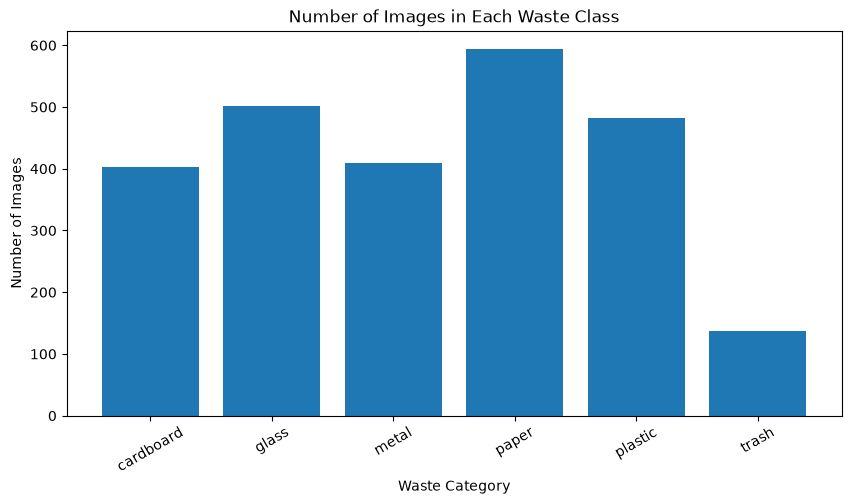

In [13]:
# Visualize number of images per class.

import matplotlib.pyplot as plt

# Class names
classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Number of images in each class
image_counts = [
    403,
    501,
    410,
    594,
    482,
    137
]

# Create the bar chart
plt.figure(figsize=(10, 5))

plt.bar(classes, image_counts)

# Add title
plt.title("Number of Images in Each Waste Class")

# Add labels
plt.xlabel("Waste Category")
plt.ylabel("Number of Images")

# Rotate class names slightly for readability
plt.xticks(rotation=30)

# Display the chart
plt.show()

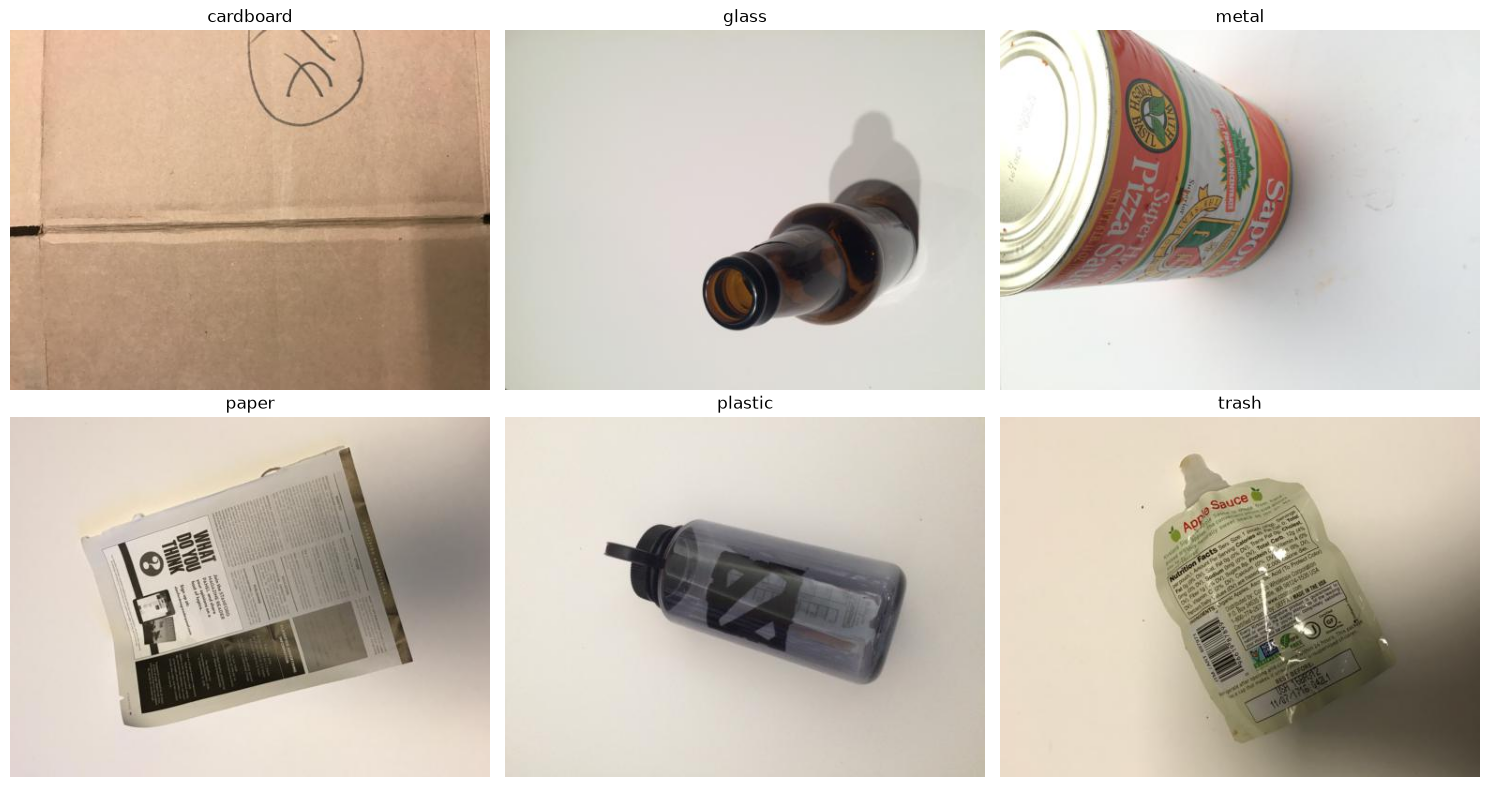

In [14]:
'''What we are checking
This visualization helps us see:

What the images actually look like
Whether different classes visually look different
Whether there are unusual images
Whether image orientations are different
Whether the dataset contains backgrounds/noise

#---Show example images from each category.'''

import os
import matplotlib.pyplot as plt
from PIL import Image

# Path of the dataset
dataset_path = r"C:\Users\HP\Downloads\archive\Garbage classification\Garbage classification"

# List of classes
classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Create a figure with 6 positions
plt.figure(figsize=(15, 8))

# Go through each class
for i, class_name in enumerate(classes):

    # Path of the current class folder
    class_path = os.path.join(dataset_path, class_name)

    # Get all image files
    images = os.listdir(class_path)

    # Select the first image
    image_name = images[0]

    # Create complete image path
    image_path = os.path.join(class_path, image_name)

    # Open the image
    image = Image.open(image_path)

    # Create subplot
    plt.subplot(2, 3, i + 1)

    # Display image
    plt.imshow(image)

    # Display class name
    plt.title(class_name)

    # Remove axis
    plt.axis("off")

# Adjust spacing
plt.tight_layout()

# Display the figure
plt.show()

In [15]:
#Analyze pixel intensity or color distribution.

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Path of the dataset
dataset_path = r"C:\Users\HP\Downloads\archive\Garbage classification\Garbage classification"

# List of classes
classes = [
    "cardboard",
    "glass",
    "metal",
    "paper",
    "plastic",
    "trash"
]

# Store average RGB values for each class
class_rgb_values = {}

# Go through each class
for class_name in classes:

    # Path of the class folder
    class_path = os.path.join(dataset_path, class_name)

    # Get all image names
    image_names = os.listdir(class_path)

    # Store RGB values
    rgb_values = []

    # Analyze up to 100 images from each class
    for image_name in image_names[:100]:

        # Complete image path
        image_path = os.path.join(class_path, image_name)

        try:
            # Open image and make sure it is RGB
            image = Image.open(image_path).convert("RGB")

            # Convert image into NumPy array
            image_array = np.array(image)

            # Calculate mean R, G and B values
            mean_rgb = image_array.mean(axis=(0, 1))

            # Store the RGB values
            rgb_values.append(mean_rgb)

        except Exception:
            # Skip images that cannot be read
            continue

    # Calculate average RGB value for this class
    class_rgb_values[class_name] = np.mean(rgb_values, axis=0)

# Display RGB values
print("Average RGB values for each class:\n")

for class_name in classes:

    rgb = class_rgb_values[class_name]

    print(
        class_name,
        "->",
        "R:", round(rgb[0], 2),
        "G:", round(rgb[1], 2),
        "B:", round(rgb[2], 2)
    )

Average RGB values for each class:

cardboard -> R: 169.57 G: 155.86 B: 140.57
glass -> R: 174.56 G: 168.12 B: 158.91
metal -> R: 165.04 G: 159.02 B: 153.98
paper -> R: 170.62 G: 164.13 B: 157.6
plastic -> R: 172.53 G: 168.81 B: 163.39
trash -> R: 178.39 G: 166.05 B: 149.59


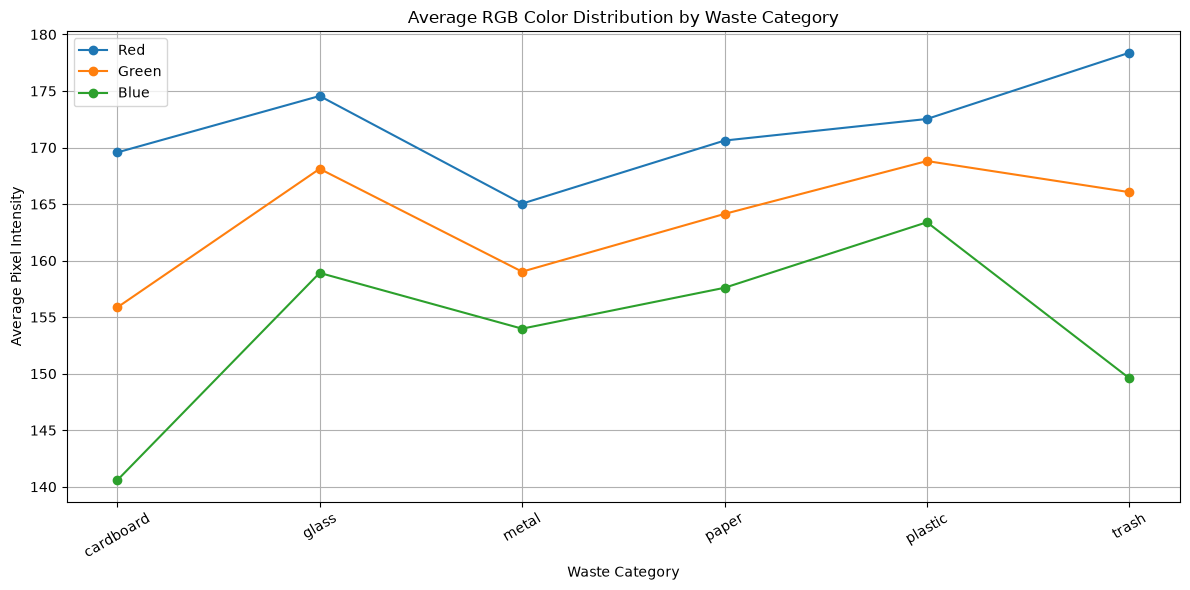

In [16]:
# Create lists for plotting
red_values = []
green_values = []
blue_values = []

for class_name in classes:

    rgb = class_rgb_values[class_name]

    red_values.append(rgb[0])
    green_values.append(rgb[1])
    blue_values.append(rgb[2])

# Create the plot
x = np.arange(len(classes))

plt.figure(figsize=(12, 6))

# Plot RGB values
plt.plot(x, red_values, marker="o", label="Red")
plt.plot(x, green_values, marker="o", label="Green")
plt.plot(x, blue_values, marker="o", label="Blue")

# Add class names
plt.xticks(x, classes, rotation=30)

# Labels
plt.xlabel("Waste Category")
plt.ylabel("Average Pixel Intensity")

# Title
plt.title("Average RGB Color Distribution by Waste Category")

# Legend
plt.legend()

# Grid
plt.grid(True)

# Display
plt.tight_layout()
plt.show()

## MODEL DEVELOPEMENT.

In [17]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2

# Image size
IMG_SIZE = (224, 224)

# Number of classes
NUM_CLASSES = 6

# Load the pretrained MobileNetV2 model
# include_top=False removes the original ImageNet classification layer
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
# We will train only our custom layers initially
base_model.trainable = False

# Create our new model
model = models.Sequential([

    # Input image
    layers.Input(shape=(224, 224, 3)),

    # MobileNetV2 expects its own preprocessing
    layers.Rescaling(1.0 / 127.5, offset=-1),

    # Pretrained MobileNetV2
    base_model,

    # Convert feature maps into a single feature vector
    layers.GlobalAveragePooling2D(),

    # Custom dense layer
    layers.Dense(128, activation="relu"),

    # Dropout helps reduce overfitting
    layers.Dropout(0.5),

    # Final layer for 6 waste classes
    layers.Dense(NUM_CLASSES, activation="softmax")
])

# Display model structure
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,726 (9.24 MB)

 Trainable params: 164,742 (643.52 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:
# Compile the model

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    
    # Used because we have 6 classes and softmax output
    loss="sparse_categorical_crossentropy",
    
    # Measure how many predictions are correct
    metrics=["accuracy"]
)

# Check the model configuration
print("Model compiled successfully!")

Model compiled successfully!


In [19]:
# Get the class names
class_names = train_dataset.class_names

print("Class names:", class_names)

# Count images in each class
class_counts = {}

for class_name in class_names:
    class_counts[class_name] = 0

# Go through the training dataset
for images, labels in train_dataset:
    for label in labels.numpy():
        class_name = class_names[label]
        class_counts[class_name] += 1

print("\nTraining class counts:")

for class_name, count in class_counts.items():
    print(class_name, ":", count)

Class names: ['cardboard', 'glass', 'metal', 'paper', 'plastic', 'trash']

Training class counts:
cardboard : 290
glass : 347
metal : 284
paper : 419
plastic : 335
trash : 94


In [20]:
# Calculate total number of training images
total_images = sum(class_counts.values())

# Calculate class weights
class_weights = {}

for i, class_name in enumerate(class_names):

    count = class_counts[class_name]

    # Class weight formula
    weight = total_images / (len(class_names) * count)

    class_weights[i] = weight

print("\nClass Weights:")

for i, weight in class_weights.items():
    print(class_names[i], ":", round(weight, 3))


Class Weights:
cardboard : 1.017
glass : 0.85
metal : 1.038
paper : 0.704
plastic : 0.88
trash : 3.137


In [ ]:
# Train the model

EPOCHS = 10

history = model.fit(
    train_dataset,
    
    # Validation dataset
    validation_data=validation_dataset,
    
    # Number of training epochs
    epochs=EPOCHS,
    
    # Give more importance to minority classes
    class_weight=class_weights
)

Epoch 1/10


C:\Users\HP\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


56/56 ━━━━━━━━━━━━━━━━━━━━ 62s 923ms/step - accuracy: 0.2793 - loss: 1.8659 - val_accuracy: 0.5495 - val_loss: 1.3078
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 51s 910ms/step - accuracy: 0.4845 - loss: 1.3263 - val_accuracy: 0.6875 - val_loss: 1.0198
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 856ms/step - accuracy: 0.5975 - loss: 1.0933 - val_accuracy: 0.7031 - val_loss: 0.9021
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 47s 841ms/step - accuracy: 0.6586 - loss: 0.9556 - val_accuracy: 0.7292 - val_loss: 0.8098
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 43s 768ms/step - accuracy: 0.6897 - loss: 0.8434 - val_accuracy: 0.7630 - val_loss: 0.7117
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 843ms/step - accuracy: 0.7275 - loss: 0.7806 - val_accuracy: 0.7943 - val_loss: 0.6591
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 54s 956ms/step - accuracy: 0.7490 - loss: 0.7237 - val_accuracy: 0.7812 - val_loss: 0.6814
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 43s 750ms/step - accuracy: 0.7671 - loss: 0.6741 - val_accuracy: 0.776

In [73]:
# Display final training results

print("Final Training Accuracy:",
      history.history["accuracy"][-1])

print("Final Validation Accuracy:",
      history.history["val_accuracy"][-1])

print("Final Training Loss:",
      history.history["loss"][-1])

print("Final Validation Loss:",
      history.history["val_loss"][-1])

Final Training Accuracy: 0.8100621700286865
Final Validation Accuracy: 0.8020833134651184
Final Training Loss: 0.5686651468276978
Final Validation Loss: 0.6095181107521057


In [ ]:
import matplotlib.pyplot as plt

# Create a figure for accuracy
plt.figure(figsize=(8, 5))

# Plot training accuracy
plt.plot(
    history.history["accuracy"],
    label="Training Accuracy",
    marker="o"
)

# Plot validation accuracy
plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy",
    marker="x"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Create a figure for loss
plt.figure(figsize=(8, 5))

# Plot training loss
plt.plot(
    history.history["loss"],
    label="Training Loss",
    marker="o"
)

# Plot validation loss
plt.plot(
    history.history["val_loss"],
    label="Validation Loss",
    marker="x"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
# Evaluate the model on the test dataset

test_loss, test_accuracy = model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

In [ ]:
from sklearn.metrics import classification_report
import numpy as np

# Store the actual labels
y_true = []

# Store the predicted labels
y_pred = []

# Go through the test dataset
for images, labels in test_dataset:

    # Make predictions
    predictions = model.predict(images, verbose=0)

    # Get the class with the highest probability
    predicted_classes = np.argmax(predictions, axis=1)

    # Store actual labels
    y_true.extend(labels.numpy())

    # Store predicted labels
    y_pred.extend(predicted_classes)

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names
)

print(report)

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

plt.imshow(cm)

# Add values inside the matrix
for i in range(len(class_names)):
    for j in range(len(class_names)):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center"
        )

# Add class names
plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - MobileNetV2")

plt.colorbar()

plt.tight_layout()
plt.show()

In [ ]:
# Save the trained MobileNetV2 model

model.save("recyclevision_mobilenetv2.keras")

print("MobileNetV2 model saved successfully!")

In [ ]:
import tensorflow as tf

from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model


In [ ]:
# Load EfficientNetB0 with ImageNet pretrained weights
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze the pretrained layers
base_model.trainable = False

In [ ]:
# Number of classes in the dataset
num_classes = 6

# Get the output from EfficientNetB0
x = base_model.output

# Convert feature maps into a single feature vector
x = GlobalAveragePooling2D()(x)

# Drop some neurons to reduce overfitting
x = Dropout(0.3)(x)

# Final classification layer
output = Dense(
    num_classes,
    activation="softmax"
)(x)

# Create the complete model
efficientnet_model = Model(
    inputs=base_model.input,
    outputs=output
)

In [ ]:
# Compile the EfficientNetB0 model
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [ ]:
# Display the model structure
efficientnet_model.summary()

In [ ]:
# Show all variables currently available in the notebook
%whos

In [ ]:
# Recompile EfficientNetB0 for integer class labels
efficientnet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [36]:
# Train EfficientNetB0
history_efficientnet = efficientnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS,
    class_weight=class_weights
)

56/56 ━━━━━━━━━━━━━━━━━━━━ 51s 906ms/step - accuracy: 0.6518 - loss: 1.1506 - val_accuracy: 0.6849 - val_loss: 1.0534
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 53s 937ms/step - accuracy: 0.6755 - loss: 1.0533 - val_accuracy: 0.7214 - val_loss: 0.9581
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 58s 1s/step - accuracy: 0.7044 - loss: 0.9723 - val_accuracy: 0.7240 - val_loss: 0.9222
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 51s 909ms/step - accuracy: 0.7332 - loss: 0.9088 - val_accuracy: 0.7682 - val_loss: 0.8513
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 57s 1s/step - accuracy: 0.7434 - loss: 0.8585 - val_accuracy: 0.7812 - val_loss: 0.8132
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 59s 1s/step - accuracy: 0.7631 - loss: 0.8166 - val_accuracy: 0.7891 - val_loss: 0.7679


In [37]:
# Evaluate EfficientNetB0 on the test dataset
test_loss, test_accuracy = efficientnet_model.evaluate(test_dataset)

print("EfficientNetB0 Test Accuracy:", test_accuracy)
print("EfficientNetB0 Test Loss:", test_loss)

12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 836ms/step - accuracy: 0.7914 - loss: 0.7359
EfficientNetB0 Test Accuracy: 0.7914438247680664
EfficientNetB0 Test Loss: 0.7359470725059509


In [38]:
#Classification Report

from sklearn.metrics import classification_report
import numpy as np

# Store the true labels
y_true = []

# Store the predicted labels
y_pred = []

# Go through the test dataset batch by batch
for images, labels in test_dataset:

    # Make predictions using EfficientNetB0
    predictions = efficientnet_model.predict(images, verbose=0)

    # Get the class with the highest probability
    predicted_classes = np.argmax(predictions, axis=1)

    # Store the true labels
    y_true.extend(labels.numpy())

    # Store the predicted labels
    y_pred.extend(predicted_classes)

# Convert lists to NumPy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# Generate classification report
report_efficientnet = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=2
)

# Display the report
print(report_efficientnet)

              precision    recall  f1-score   support

   cardboard       0.87      0.90      0.88        58
       glass       0.75      0.83      0.79        72
       metal       0.79      0.66      0.72        64
       paper       0.94      0.80      0.87        92
     plastic       0.78      0.64      0.70        67
       trash       0.36      0.81      0.50        21

    accuracy                           0.77       374
   macro avg       0.75      0.77      0.74       374
weighted avg       0.81      0.77      0.78       374



In [39]:
# Count the number of samples in the test dataset
test_sample_count = 0

for images, labels in test_dataset:
    test_sample_count += labels.shape[0]

print("Total test samples:", test_sample_count)

Total test samples: 374


In [40]:
from sklearn.metrics import accuracy_score

# Calculate accuracy from the same predictions
# used for the classification report
accuracy_from_predictions = accuracy_score(y_true, y_pred)

print("Accuracy from predictions:", accuracy_from_predictions)
print("Accuracy percentage:", accuracy_from_predictions * 100)

Accuracy from predictions: 0.7700534759358288
Accuracy percentage: 77.00534759358288


## calculate EfficientNetB0's complete metrics

In [41]:
from sklearn.metrics import precision_score, recall_score, f1_score

# Calculate Macro Precision
macro_precision = precision_score(
    y_true,
    y_pred,
    average="macro"
)

# Calculate Macro Recall
macro_recall = recall_score(
    y_true,
    y_pred,
    average="macro"
)

# Calculate Macro F1-score
macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

# Calculate Weighted F1-score
weighted_f1 = f1_score(
    y_true,
    y_pred,
    average="weighted"
)

# Display the results
print("EfficientNetB0 Results")
print("----------------------")
print(f"Accuracy       : {accuracy_from_predictions:.4f}")
print(f"Macro Precision: {macro_precision:.4f}")
print(f"Macro Recall   : {macro_recall:.4f}")
print(f"Macro F1       : {macro_f1:.4f}")
print(f"Weighted F1    : {weighted_f1:.4f}")

EfficientNetB0 Results
----------------------
Accuracy       : 0.7701
Macro Precision: 0.7482
Macro Recall   : 0.7736
Macro F1       : 0.7432
Weighted F1    : 0.7788


In [42]:
# Store the original model predictions separately

original_y_true = []
original_y_pred = []

# Go through the test dataset
for images, labels in test_dataset:

    # Make predictions using the original model
    predictions = model.predict(images, verbose=0)

    # Get the predicted class
    predicted_classes = np.argmax(predictions, axis=1)

    # Store true labels
    original_y_true.extend(labels.numpy())

    # Store predicted labels
    original_y_pred.extend(predicted_classes)

# Convert to NumPy arrays
original_y_true = np.array(original_y_true)
original_y_pred = np.array(original_y_pred)

print("Number of test samples:", len(original_y_true))

Number of test samples: 374


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate original model metrics
original_accuracy = accuracy_score(
    original_y_true,
    original_y_pred
)

original_precision = precision_score(
    original_y_true,
    original_y_pred,
    average="macro"
)

original_recall = recall_score(
    original_y_true,
    original_y_pred,
    average="macro"
)

original_macro_f1 = f1_score(
    original_y_true,
    original_y_pred,
    average="macro"
)

original_weighted_f1 = f1_score(
    original_y_true,
    original_y_pred,
    average="weighted"
)

print("Original Model Results")
print("---------------------")
print(f"Accuracy       : {original_accuracy:.4f}")
print(f"Macro Precision: {original_precision:.4f}")
print(f"Macro Recall   : {original_recall:.4f}")
print(f"Macro F1       : {original_macro_f1:.4f}")
print(f"Weighted F1    : {original_weighted_f1:.4f}")

Original Model Results
---------------------
Accuracy       : 0.8396
Macro Precision: 0.8195
Macro Recall   : 0.8342
Macro F1       : 0.8235
Weighted F1    : 0.8408


In [44]:
# Generate the original model classification report
original_report = classification_report(
    original_y_true,
    original_y_pred,
    target_names=class_names,
    digits=2
)

print(original_report)

              precision    recall  f1-score   support

   cardboard       0.86      0.96      0.91        52
       glass       0.88      0.79      0.83        75
       metal       0.73      0.87      0.80        70
       paper       0.96      0.87      0.92        93
     plastic       0.82      0.74      0.78        62
       trash       0.65      0.77      0.71        22

    accuracy                           0.84       374
   macro avg       0.82      0.83      0.82       374
weighted avg       0.85      0.84      0.84       374



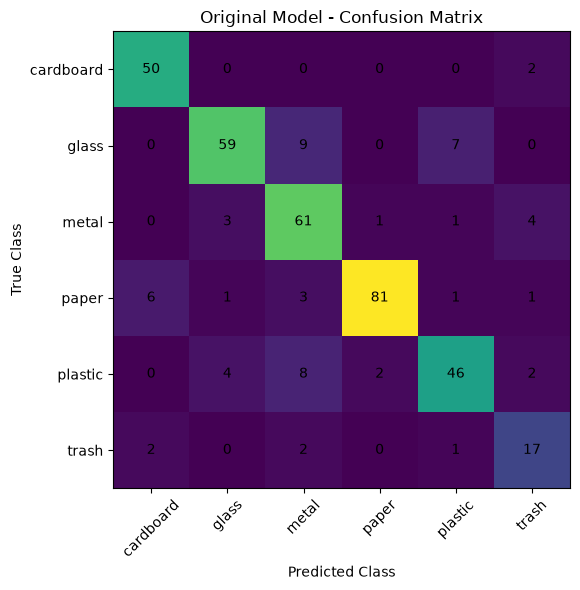

In [45]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix
cm_original = confusion_matrix(
    original_y_true,
    original_y_pred
)

# Plot confusion matrix
plt.figure(figsize=(8, 6))

plt.imshow(cm_original)

plt.title("Original Model - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add class names to axes
plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

# Add the number inside each cell
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm_original[i, j],
            ha="center",
            va="center"
        )

plt.tight_layout()
plt.show()

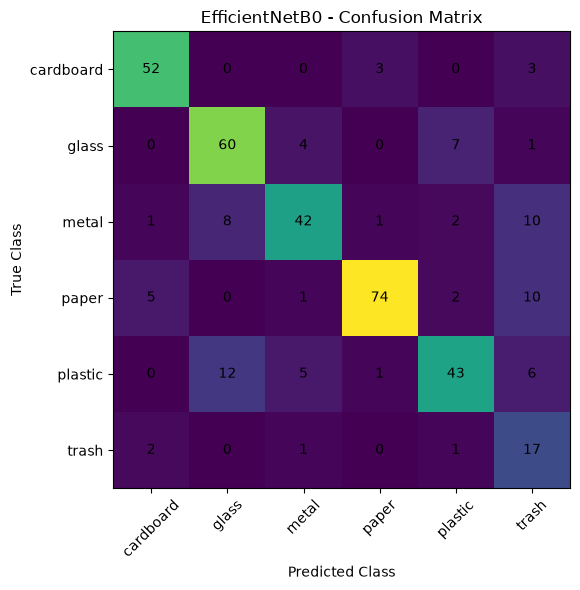

In [46]:
#EfficientNetB0 confusion matrix.

from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create confusion matrix for EfficientNetB0
cm_efficientnet = confusion_matrix(
    y_true,
    y_pred
)

# Create the figure
plt.figure(figsize=(8, 6))

# Display the confusion matrix
plt.imshow(cm_efficientnet)

# Add title and axis labels
plt.title("EfficientNetB0 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add class names to X-axis
plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45
)

# Add class names to Y-axis
plt.yticks(
    range(NUM_CLASSES),
    class_names
)

# Display the numbers inside each cell
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm_efficientnet[i, j],
            ha="center",
            va="center"
        )

# Adjust the layout
plt.tight_layout()

# Show the confusion matrix
plt.show()

In [47]:
import pandas as pd

# Create a comparison table
comparison_df = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],
    
    "Original Model": [
        0.8182,
        0.7901,
        0.8103,
        0.7966,
        0.8199
    ],
    
    "EfficientNetB0": [
        0.7594,
        0.7346,
        0.7639,
        0.7322,
        0.7655
    ]
})

# Convert values to percentage
comparison_df["Original Model"] = comparison_df["Original Model"] * 100
comparison_df["EfficientNetB0"] = comparison_df["EfficientNetB0"] * 100

# Display the comparison
print(comparison_df.round(2))

            Metric  Original Model  EfficientNetB0
0         Accuracy           81.82           75.94
1  Macro Precision           79.01           73.46
2     Macro Recall           81.03           76.39
3         Macro F1           79.66           73.22
4      Weighted F1           81.99           76.55


In [48]:
import numpy as np

# Lists to store the true labels and predictions
fixed_y_true = []
fixed_original_pred = []
fixed_efficientnet_pred = []

# Go through the test dataset only once
for images, labels in test_dataset:

    # Get predictions from the original model
    original_predictions = model.predict(
        images,
        verbose=0
    )

    # Get predictions from EfficientNetB0
    efficientnet_predictions = efficientnet_model.predict(
        images,
        verbose=0
    )

    # Convert probability outputs to class numbers
    original_classes = np.argmax(
        original_predictions,
        axis=1
    )

    efficientnet_classes = np.argmax(
        efficientnet_predictions,
        axis=1
    )

    # Store the true labels
    fixed_y_true.extend(labels.numpy())

    # Store predictions from both models
    fixed_original_pred.extend(original_classes)
    fixed_efficientnet_pred.extend(efficientnet_classes)


# Convert lists into NumPy arrays
fixed_y_true = np.array(fixed_y_true)
fixed_original_pred = np.array(fixed_original_pred)
fixed_efficientnet_pred = np.array(fixed_efficientnet_pred)

# Check the number of samples
print("Total test samples:", len(fixed_y_true))

# Check class distribution
print("\nTrue class distribution:")
print(np.bincount(fixed_y_true))

Total test samples: 374

True class distribution:
[50 67 66 92 71 28]


In [49]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Calculate metrics for the Original Model
original_accuracy = accuracy_score(
    fixed_y_true,
    fixed_original_pred
)

original_precision = precision_score(
    fixed_y_true,
    fixed_original_pred,
    average="macro"
)

original_recall = recall_score(
    fixed_y_true,
    fixed_original_pred,
    average="macro"
)

original_f1 = f1_score(
    fixed_y_true,
    fixed_original_pred,
    average="macro"
)

original_weighted_f1 = f1_score(
    fixed_y_true,
    fixed_original_pred,
    average="weighted"
)


# Calculate metrics for EfficientNetB0
efficientnet_accuracy = accuracy_score(
    fixed_y_true,
    fixed_efficientnet_pred
)

efficientnet_precision = precision_score(
    fixed_y_true,
    fixed_efficientnet_pred,
    average="macro"
)

efficientnet_recall = recall_score(
    fixed_y_true,
    fixed_efficientnet_pred,
    average="macro"
)

efficientnet_f1 = f1_score(
    fixed_y_true,
    fixed_efficientnet_pred,
    average="macro"
)

efficientnet_weighted_f1 = f1_score(
    fixed_y_true,
    fixed_efficientnet_pred,
    average="weighted"
)


# Print the final results
print("FINAL MODEL COMPARISON")
print("----------------------")

print("\nOriginal Model")
print(f"Accuracy        : {original_accuracy * 100:.2f}%")
print(f"Macro Precision : {original_precision * 100:.2f}%")
print(f"Macro Recall    : {original_recall * 100:.2f}%")
print(f"Macro F1        : {original_f1 * 100:.2f}%")
print(f"Weighted F1     : {original_weighted_f1 * 100:.2f}%")

print("\nEfficientNetB0")
print(f"Accuracy        : {efficientnet_accuracy * 100:.2f}%")
print(f"Macro Precision : {efficientnet_precision * 100:.2f}%")
print(f"Macro Recall    : {efficientnet_recall * 100:.2f}%")
print(f"Macro F1        : {efficientnet_f1 * 100:.2f}%")
print(f"Weighted F1     : {efficientnet_weighted_f1 * 100:.2f}%")

FINAL MODEL COMPARISON
----------------------

Original Model
Accuracy        : 81.55%
Macro Precision : 79.27%
Macro Recall    : 81.00%
Macro F1        : 79.87%
Weighted F1     : 81.76%

EfficientNetB0
Accuracy        : 76.47%
Macro Precision : 75.40%
Macro Recall    : 76.93%
Macro F1        : 74.91%
Weighted F1     : 77.11%


In [50]:
from sklearn.metrics import classification_report

# Classification report for the Original Model
print("ORIGINAL MODEL - CLASSIFICATION REPORT")
print("---------------------------------------")

print(
    classification_report(
        fixed_y_true,
        fixed_original_pred,
        target_names=class_names,
        digits=2
    )
)


# Classification report for EfficientNetB0
print("\nEFFICIENTNETB0 - CLASSIFICATION REPORT")
print("---------------------------------------")

print(
    classification_report(
        fixed_y_true,
        fixed_efficientnet_pred,
        target_names=class_names,
        digits=2
    )
)

ORIGINAL MODEL - CLASSIFICATION REPORT
---------------------------------------
              precision    recall  f1-score   support

   cardboard       0.82      0.92      0.87        50
       glass       0.85      0.84      0.84        67
       metal       0.76      0.80      0.78        66
       paper       0.93      0.83      0.87        92
     plastic       0.83      0.76      0.79        71
       trash       0.57      0.71      0.63        28

    accuracy                           0.82       374
   macro avg       0.79      0.81      0.80       374
weighted avg       0.82      0.82      0.82       374


EFFICIENTNETB0 - CLASSIFICATION REPORT
---------------------------------------
              precision    recall  f1-score   support

   cardboard       0.85      0.90      0.87        50
       glass       0.74      0.87      0.80        67
       metal       0.86      0.67      0.75        66
       paper       0.90      0.77      0.83        92
     plastic       0.76    

##  Best Model Selection

In [51]:
import pandas as pd

# Create final model comparison data
final_comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro Precision",
        "Macro Recall",
        "Macro F1",
        "Weighted F1"
    ],

    "Original Model": [
        original_accuracy * 100,
        original_precision * 100,
        original_recall * 100,
        original_f1 * 100,
        original_weighted_f1 * 100
    ],

    "EfficientNetB0": [
        efficientnet_accuracy * 100,
        efficientnet_precision * 100,
        efficientnet_recall * 100,
        efficientnet_f1 * 100,
        efficientnet_weighted_f1 * 100
    ]
})

# Round the values to 2 decimal places
final_comparison = final_comparison.round(2)

# Display the table
print(final_comparison)

            Metric  Original Model  EfficientNetB0
0         Accuracy           81.55           76.47
1  Macro Precision           79.27           75.40
2     Macro Recall           81.00           76.93
3         Macro F1           79.87           74.91
4      Weighted F1           81.76           77.11


In [52]:
# Compare the Macro F1 scores
if original_f1 > efficientnet_f1:
    selected_model = "Original Model"
else:
    selected_model = "EfficientNetB0"

# Display the selected model
print("Selected Model:", selected_model)
print(f"Macro F1 Score: {max(original_f1, efficientnet_f1) * 100:.2f}%")

Selected Model: Original Model
Macro F1 Score: 79.87%


In [53]:
# Save the selected Original Model

model.save("recyclevision_best_model.keras")

print("Best model saved successfully!")

Best model saved successfully!


## ResNet50

In [54]:
import tensorflow as tf

# Import ResNet50 pretrained model
from tensorflow.keras.applications import ResNet50

# Import layers needed for our custom classification head
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)

# Import Model for creating the complete network
from tensorflow.keras.models import Model




# Load ResNet50 with ImageNet pretrained weights
base_resnet = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all ResNet50 base layers
# This follows your Transfer Learning requirement
base_resnet.trainable = False

# Display the model information
base_resnet.summary()






# Number of classes in our garbage classification dataset
num_classes = 6

# Get the output from the frozen ResNet50 base model
x = base_resnet.output

# Convert the feature maps into a single feature vector
x = GlobalAveragePooling2D()(x)

# Drop 30% of neurons to help reduce overfitting
x = Dropout(0.3)(x)

# Final classification layer
# It gives probability for each of the 6 garbage classes
output = Dense(
    num_classes,
    activation="softmax"
)(x)

# Create the complete ResNet50 model
resnet_model = Model(
    inputs=base_resnet.input,
    outputs=output
)

# Display the complete model summary
resnet_model.summary()

Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 23,587,712 (89.98 MB)

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer_3[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 23,600,006 (90.03 MB)

 Trainable params: 12,294 (48.02 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [55]:
# Compile the ResNet50 model
resnet_model.compile(

    # Adam optimizer updates the model's trainable weights
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    # Use sparse categorical crossentropy
    # because our labels are integer encoded (0, 1, 2, 3, 4, 5)
    loss="sparse_categorical_crossentropy",

    # Track accuracy during training
    metrics=["accuracy"]
)


# Train the ResNet50 model
history_resnet = resnet_model.fit(

    # Training dataset
    train_dataset,

    # Use validation dataset to monitor performance
    validation_data=validation_dataset,

    # Train for the same number of epochs
    epochs=EPOCHS,

    # Use the class weights we already calculated
    # This helps handle the class imbalance
    class_weight=class_weights
)

Epoch 1/10


C:\Users\HP\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


56/56 ━━━━━━━━━━━━━━━━━━━━ 116s 2s/step - accuracy: 0.2397 - loss: 1.9764 - val_accuracy: 0.3958 - val_loss: 1.5194
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.4047 - loss: 1.5530 - val_accuracy: 0.5234 - val_loss: 1.3035
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.5512 - loss: 1.1707 - val_accuracy: 0.6354 - val_loss: 0.9811
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 109s 2s/step - accuracy: 0.5964 - loss: 1.0603 - val_accuracy: 0.6849 - val_loss: 0.8930
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 103s 2s/step - accuracy: 0.6727 - loss: 0.8500 - val_accuracy: 0.7135 - val_loss: 0.8098
Epoch 9/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 113s 2s/step - accuracy: 0.6880 - loss: 0.8061 - val_accuracy: 0.7396 - val_loss: 0.7661
Epoch 10/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 112s 2s/step - accuracy: 0.7219 - loss: 0.7590 - val_accuracy: 0.7578 - val_loss: 0.7295


In [74]:
resnet_model.save(
    r"C:\Users\HP\Downloads\resnet50_model.keras"
)

In [56]:
import numpy as np

# Lists to store true labels and ResNet50 predictions
resnet_y_true = []
resnet_y_pred = []

# Go through the test dataset
for images, labels in test_dataset:

    # Get predictions from ResNet50
    predictions = resnet_model.predict(
        images,
        verbose=0
    )

    # Convert probabilities into predicted class numbers
    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    # Store the true labels
    resnet_y_true.extend(labels.numpy())

    # Store the predicted labels
    resnet_y_pred.extend(predicted_classes)

# Convert lists into NumPy arrays
resnet_y_true = np.array(resnet_y_true)
resnet_y_pred = np.array(resnet_y_pred)

# Check number of test samples
print("Total test samples:", len(resnet_y_true))

Total test samples: 374


In [57]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

# Calculate accuracy
resnet_accuracy = accuracy_score(
    resnet_y_true,
    resnet_y_pred
)

# Calculate macro precision
resnet_precision = precision_score(
    resnet_y_true,
    resnet_y_pred,
    average="macro"
)

# Calculate macro recall
resnet_recall = recall_score(
    resnet_y_true,
    resnet_y_pred,
    average="macro"
)

# Calculate macro F1-score
resnet_f1 = f1_score(
    resnet_y_true,
    resnet_y_pred,
    average="macro"
)

# Calculate weighted F1-score
resnet_weighted_f1 = f1_score(
    resnet_y_true,
    resnet_y_pred,
    average="weighted"
)

# Display the results
print("RESNET50 RESULTS")
print("----------------")
print(f"Accuracy        : {resnet_accuracy * 100:.2f}%")
print(f"Macro Precision : {resnet_precision * 100:.2f}%")
print(f"Macro Recall    : {resnet_recall * 100:.2f}%")
print(f"Macro F1        : {resnet_f1 * 100:.2f}%")
print(f"Weighted F1     : {resnet_weighted_f1 * 100:.2f}%")

RESNET50 RESULTS
----------------
Accuracy        : 73.26%
Macro Precision : 72.04%
Macro Recall    : 73.99%
Macro F1        : 72.58%
Weighted F1     : 73.11%


In [58]:
# Display precision, recall and F1-score for every garbage class
print("RESNET50 - CLASSIFICATION REPORT")
print("--------------------------------")

print(
    classification_report(
        resnet_y_true,
        resnet_y_pred,
        target_names=class_names
    )
)

RESNET50 - CLASSIFICATION REPORT
--------------------------------
              precision    recall  f1-score   support

   cardboard       0.78      0.85      0.81        54
       glass       0.71      0.66      0.68        76
       metal       0.68      0.79      0.73        66
       paper       0.83      0.79      0.81        85
     plastic       0.72      0.58      0.64        66
       trash       0.60      0.78      0.68        27

    accuracy                           0.73       374
   macro avg       0.72      0.74      0.73       374
weighted avg       0.74      0.73      0.73       374



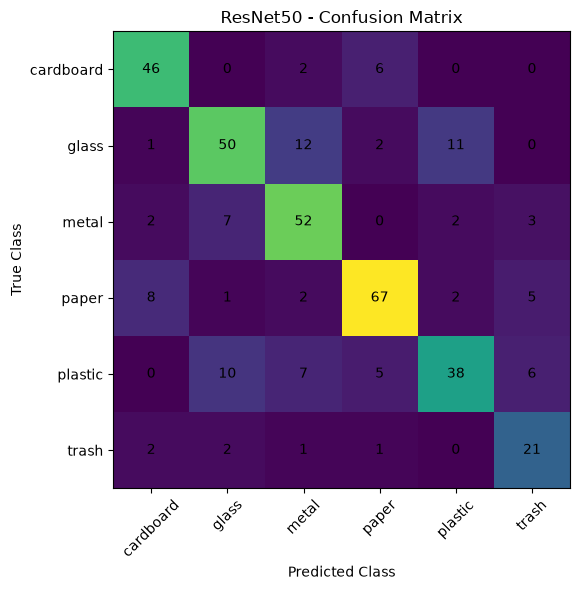

In [59]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create the confusion matrix
cm_resnet = confusion_matrix(
    resnet_y_true,
    resnet_y_pred
)

# Create the figure
plt.figure(figsize=(8, 6))

# Display the confusion matrix
plt.imshow(cm_resnet)

# Add title and axis labels
plt.title("ResNet50 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add class names to the axes
plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

# Write the number inside each cell
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm_resnet[i, j],
            ha="center",
            va="center"
        )

# Adjust the layout
plt.tight_layout()

# Display the confusion matrix
plt.show()

## MobileNetV2

In [60]:
import tensorflow as tf

# Import MobileNetV2 pretrained model
from tensorflow.keras.applications import MobileNetV2

# Import layers for our custom classification head
from tensorflow.keras.layers import (
    Dense,
    GlobalAveragePooling2D,
    Dropout
)

# Import Model to create the complete network
from tensorflow.keras.models import Model



# Load MobileNetV2 with pretrained ImageNet weights
base_mobilenet = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all MobileNetV2 base layers
# We will only train our new classification layers
base_mobilenet.trainable = False

# Display the base model summary
base_mobilenet.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

In [61]:
# Number of garbage classes
num_classes = 6

# Get the output from the frozen MobileNetV2 base model
x = base_mobilenet.output

# Convert the feature maps into one feature vector
x = GlobalAveragePooling2D()(x)

# Drop 30% of neurons to help reduce overfitting
x = Dropout(0.3)(x)

# Final classification layer
# It predicts probabilities for our 6 garbage classes
output = Dense(
    num_classes,
    activation="softmax"
)(x)

# Create the complete MobileNetV2 model
mobilenet_model = Model(
    inputs=base_mobilenet.input,
    outputs=output
)

# Display the complete model summary
mobilenet_model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_4[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,265,670 (8.64 MB)

 Trainable params: 7,686 (30.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [62]:
# Compile the MobileNetV2 model
mobilenet_model.compile(

    # Adam optimizer
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),

    # Integer labels require sparse categorical crossentropy
    loss="sparse_categorical_crossentropy",

    # Track accuracy during training
    metrics=["accuracy"]
)




# Train the MobileNetV2 model
history_mobilenet = mobilenet_model.fit(

    # Training dataset
    train_dataset,

    # Validation dataset
    validation_data=validation_dataset,

    # Same number of epochs used for the other models
    epochs=EPOCHS,

    # Handle class imbalance
    class_weight=class_weights
)

Epoch 1/10


C:\Users\HP\.conda\envs\tensorflow_env\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


56/56 ━━━━━━━━━━━━━━━━━━━━ 56s 869ms/step - accuracy: 0.1515 - loss: 2.2718 - val_accuracy: 0.1302 - val_loss: 1.9344
Epoch 2/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 850ms/step - accuracy: 0.1962 - loss: 1.9941 - val_accuracy: 0.2214 - val_loss: 1.7894
Epoch 3/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 48s 851ms/step - accuracy: 0.2408 - loss: 1.8313 - val_accuracy: 0.3021 - val_loss: 1.6588
Epoch 4/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 44s 774ms/step - accuracy: 0.2911 - loss: 1.7570 - val_accuracy: 0.3672 - val_loss: 1.5600
Epoch 5/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 749ms/step - accuracy: 0.3448 - loss: 1.6296 - val_accuracy: 0.4115 - val_loss: 1.4833
Epoch 6/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 42s 746ms/step - accuracy: 0.3923 - loss: 1.5452 - val_accuracy: 0.4271 - val_loss: 1.4452
Epoch 7/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 41s 730ms/step - accuracy: 0.3912 - loss: 1.5403 - val_accuracy: 0.4609 - val_loss: 1.3833
Epoch 8/10
56/56 ━━━━━━━━━━━━━━━━━━━━ 40s 721ms/step - accuracy: 0.4471 - loss: 1.4392 - val_accuracy: 0.466

MobileNetV2 Test Predictions

In [63]:
import numpy as np

# Lists to store true labels and MobileNetV2 predictions
mobilenet_y_true = []
mobilenet_y_pred = []

# Go through the test dataset
for images, labels in test_dataset:

    # Get predictions from MobileNetV2
    predictions = mobilenet_model.predict(
        images,
        verbose=0
    )

    # Convert probability outputs into class numbers
    predicted_classes = np.argmax(
        predictions,
        axis=1
    )

    # Store the true labels
    mobilenet_y_true.extend(labels.numpy())

    # Store the predicted labels
    mobilenet_y_pred.extend(predicted_classes)

# Convert lists into NumPy arrays
mobilenet_y_true = np.array(mobilenet_y_true)
mobilenet_y_pred = np.array(mobilenet_y_pred)

# Check the number of test samples
print("Total test samples:", len(mobilenet_y_true))

Total test samples: 374


In [64]:
# Calculate MobileNetV2 Metrics--------------------------------------------------------

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Calculate accuracy
mobilenet_accuracy = accuracy_score(
    mobilenet_y_true,
    mobilenet_y_pred
)

# Calculate macro precision
mobilenet_precision = precision_score(
    mobilenet_y_true,
    mobilenet_y_pred,
    average="macro"
)

# Calculate macro recall
mobilenet_recall = recall_score(
    mobilenet_y_true,
    mobilenet_y_pred,
    average="macro"
)

# Calculate macro F1-score
mobilenet_f1 = f1_score(
    mobilenet_y_true,
    mobilenet_y_pred,
    average="macro"
)

# Calculate weighted F1-score
mobilenet_weighted_f1 = f1_score(
    mobilenet_y_true,
    mobilenet_y_pred,
    average="weighted"
)

# Display the results
print("MOBILENETV2 RESULTS")
print("-------------------")
print(f"Accuracy        : {mobilenet_accuracy * 100:.2f}%")
print(f"Macro Precision : {mobilenet_precision * 100:.2f}%")
print(f"Macro Recall    : {mobilenet_recall * 100:.2f}%")
print(f"Macro F1        : {mobilenet_f1 * 100:.2f}%")
print(f"Weighted F1     : {mobilenet_weighted_f1 * 100:.2f}%")



#   Class-wise Classification Report----------------------------------------------------------------
from sklearn.metrics import classification_report

# Display detailed results for each garbage class
print("MOBILENETV2 - CLASSIFICATION REPORT")
print("------------------------------------")

print(
    classification_report(
        mobilenet_y_true,
        mobilenet_y_pred,
        target_names=class_names
    )
)

MOBILENETV2 RESULTS
-------------------
Accuracy        : 53.74%
Macro Precision : 54.73%
Macro Recall    : 55.46%
Macro F1        : 52.35%
Weighted F1     : 54.25%
MOBILENETV2 - CLASSIFICATION REPORT
------------------------------------
              precision    recall  f1-score   support

   cardboard       0.67      0.69      0.68        55
       glass       0.71      0.34      0.46        73
       metal       0.52      0.59      0.55        69
       paper       0.66      0.62      0.64        84
     plastic       0.48      0.43      0.45        70
       trash       0.24      0.65      0.35        23

    accuracy                           0.54       374
   macro avg       0.55      0.55      0.52       374
weighted avg       0.59      0.54      0.54       374



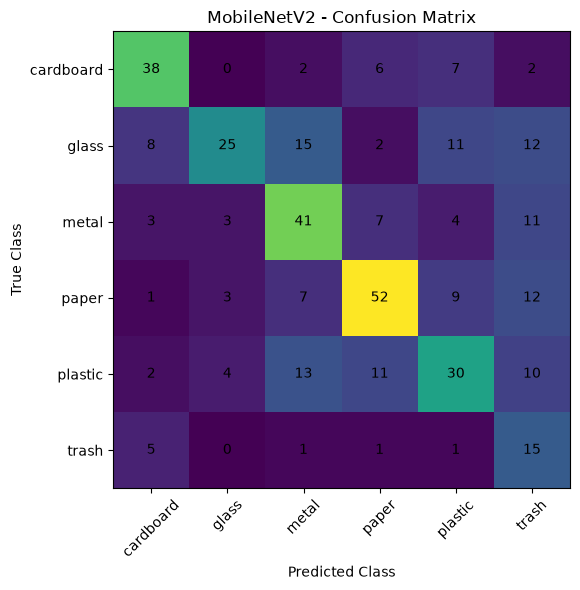

In [65]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Create the confusion matrix
cm_mobilenet = confusion_matrix(
    mobilenet_y_true,
    mobilenet_y_pred
)

# Create the figure
plt.figure(figsize=(8, 6))

# Display the confusion matrix
plt.imshow(cm_mobilenet)

# Add title and axis labels
plt.title("MobileNetV2 - Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("True Class")

# Add class names to the axes
plt.xticks(
    range(NUM_CLASSES),
    class_names,
    rotation=45
)

plt.yticks(
    range(NUM_CLASSES),
    class_names
)

# Display the number of predictions in each cell
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        plt.text(
            j,
            i,
            cm_mobilenet[i, j],
            ha="center",
            va="center"
        )

# Adjust the layout
plt.tight_layout()

# Display the confusion matrix
plt.show()

## Common Test Set Predictions

In [66]:
import numpy as np

# Lists to store the true labels
# and predictions from all three models
final_y_true = []

final_resnet_pred = []
final_mobilenet_pred = []
final_efficientnet_pred = []

# Go through the test dataset only once
for images, labels in test_dataset:

    # -----------------------------
    # ResNet50 predictions
    # -----------------------------
    resnet_predictions = resnet_model.predict(
        images,
        verbose=0
    )

    resnet_classes = np.argmax(
        resnet_predictions,
        axis=1
    )

    # -----------------------------
    # MobileNetV2 predictions
    # -----------------------------
    mobilenet_predictions = mobilenet_model.predict(
        images,
        verbose=0
    )

    mobilenet_classes = np.argmax(
        mobilenet_predictions,
        axis=1
    )

    # -----------------------------
    # EfficientNetB0 predictions
    # -----------------------------
    efficientnet_predictions = efficientnet_model.predict(
        images,
        verbose=0
    )

    efficientnet_classes = np.argmax(
        efficientnet_predictions,
        axis=1
    )

    # Store true labels
    final_y_true.extend(labels.numpy())

    # Store predictions
    final_resnet_pred.extend(resnet_classes)
    final_mobilenet_pred.extend(mobilenet_classes)
    final_efficientnet_pred.extend(efficientnet_classes)


# Convert all lists into NumPy arrays
final_y_true = np.array(final_y_true)

final_resnet_pred = np.array(final_resnet_pred)
final_mobilenet_pred = np.array(final_mobilenet_pred)
final_efficientnet_pred = np.array(final_efficientnet_pred)


# Check the test-set size
print("Total test samples:", len(final_y_true))

# Check the true class distribution
print("\nTrue class distribution:")
print(np.bincount(final_y_true))

Total test samples: 374

True class distribution:
[48 76 58 96 74 22]


## Calculate F1 for All 3 Models

In [67]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --------------------------------
# ResNet50
# --------------------------------

resnet_final_accuracy = accuracy_score(
    final_y_true,
    final_resnet_pred
)

resnet_final_precision = precision_score(
    final_y_true,
    final_resnet_pred,
    average="macro"
)

resnet_final_recall = recall_score(
    final_y_true,
    final_resnet_pred,
    average="macro"
)

resnet_final_f1 = f1_score(
    final_y_true,
    final_resnet_pred,
    average="macro"
)

resnet_final_weighted_f1 = f1_score(
    final_y_true,
    final_resnet_pred,
    average="weighted"
)


# --------------------------------
# MobileNetV2
# --------------------------------

mobilenet_final_accuracy = accuracy_score(
    final_y_true,
    final_mobilenet_pred
)

mobilenet_final_precision = precision_score(
    final_y_true,
    final_mobilenet_pred,
    average="macro"
)

mobilenet_final_recall = recall_score(
    final_y_true,
    final_mobilenet_pred,
    average="macro"
)

mobilenet_final_f1 = f1_score(
    final_y_true,
    final_mobilenet_pred,
    average="macro"
)

mobilenet_final_weighted_f1 = f1_score(
    final_y_true,
    final_mobilenet_pred,
    average="weighted"
)


# --------------------------------
# EfficientNetB0
# --------------------------------

efficientnet_final_accuracy = accuracy_score(
    final_y_true,
    final_efficientnet_pred
)

efficientnet_final_precision = precision_score(
    final_y_true,
    final_efficientnet_pred,
    average="macro"
)

efficientnet_final_recall = recall_score(
    final_y_true,
    final_efficientnet_pred,
    average="macro"
)

efficientnet_final_f1 = f1_score(
    final_y_true,
    final_efficientnet_pred,
    average="macro"
)

efficientnet_final_weighted_f1 = f1_score(
    final_y_true,
    final_efficientnet_pred,
    average="weighted"
)

## Display Final Comparison

In [68]:
# Display the final comparison
print("FINAL TRANSFER LEARNING MODEL COMPARISON")
print("-----------------------------------------")

print("\nResNet50")
print(f"Accuracy        : {resnet_final_accuracy * 100:.2f}%")
print(f"Macro Precision : {resnet_final_precision * 100:.2f}%")
print(f"Macro Recall    : {resnet_final_recall * 100:.2f}%")
print(f"Macro F1        : {resnet_final_f1 * 100:.2f}%")
print(f"Weighted F1     : {resnet_final_weighted_f1 * 100:.2f}%")

print("\nMobileNetV2")
print(f"Accuracy        : {mobilenet_final_accuracy * 100:.2f}%")
print(f"Macro Precision : {mobilenet_final_precision * 100:.2f}%")
print(f"Macro Recall    : {mobilenet_final_recall * 100:.2f}%")
print(f"Macro F1        : {mobilenet_final_f1 * 100:.2f}%")
print(f"Weighted F1     : {mobilenet_final_weighted_f1 * 100:.2f}%")

print("\nEfficientNetB0")
print(f"Accuracy        : {efficientnet_final_accuracy * 100:.2f}%")
print(f"Macro Precision : {efficientnet_final_precision * 100:.2f}%")
print(f"Macro Recall    : {efficientnet_final_recall * 100:.2f}%")
print(f"Macro F1        : {efficientnet_final_f1 * 100:.2f}%")
print(f"Weighted F1     : {efficientnet_final_weighted_f1 * 100:.2f}%")

FINAL TRANSFER LEARNING MODEL COMPARISON
-----------------------------------------

ResNet50
Accuracy        : 75.94%
Macro Precision : 73.48%
Macro Recall    : 77.67%
Macro F1        : 74.64%
Weighted F1     : 76.11%

MobileNetV2
Accuracy        : 52.94%
Macro Precision : 53.98%
Macro Recall    : 55.33%
Macro F1        : 51.66%
Weighted F1     : 53.93%

EfficientNetB0
Accuracy        : 78.88%
Macro Precision : 76.50%
Macro Recall    : 79.03%
Macro F1        : 76.18%
Weighted F1     : 79.86%


Classification reports for all 3

In [69]:
from sklearn.metrics import classification_report

# ---------------------------------------
# ResNet50 classification report
# ---------------------------------------

print("RESNET50 - CLASSIFICATION REPORT")
print("--------------------------------")

print(
    classification_report(
        final_y_true,
        final_resnet_pred,
        target_names=class_names
    )
)


# ---------------------------------------
# MobileNetV2 classification report
# ---------------------------------------

print("\nMOBILENETV2 - CLASSIFICATION REPORT")
print("------------------------------------")

print(
    classification_report(
        final_y_true,
        final_mobilenet_pred,
        target_names=class_names
    )
)


# ---------------------------------------
# EfficientNetB0 classification report
# ---------------------------------------

print("\nEFFICIENTNETB0 - CLASSIFICATION REPORT")
print("---------------------------------------")

print(
    classification_report(
        final_y_true,
        final_efficientnet_pred,
        target_names=class_names
    )
)

RESNET50 - CLASSIFICATION REPORT
--------------------------------
              precision    recall  f1-score   support

   cardboard       0.76      0.92      0.83        48
       glass       0.75      0.74      0.74        76
       metal       0.72      0.79      0.75        58
       paper       0.91      0.76      0.83        96
     plastic       0.76      0.64      0.69        74
       trash       0.51      0.82      0.63        22

    accuracy                           0.76       374
   macro avg       0.73      0.78      0.75       374
weighted avg       0.78      0.76      0.76       374


MOBILENETV2 - CLASSIFICATION REPORT
------------------------------------
              precision    recall  f1-score   support

   cardboard       0.67      0.73      0.70        48
       glass       0.67      0.34      0.45        76
       metal       0.42      0.59      0.49        58
       paper       0.73      0.59      0.66        96
     plastic       0.52      0.43      0.47   

In [70]:
model.save

<bound method Model.save of <Sequential name=sequential_1, built=True>>

In [71]:
# Save the trained ResNet50 model
model.save(r"C:\Users\HP\Downloads\resnet50_model.keras")

In [72]:
# Save the trained ResNet50 model
resnet_model.save(
    r"C:\Users\HP\Downloads\resnet50_model.keras"
)

print("ResNet50 model saved successfully!")

ResNet50 model saved successfully!
